In [ ]:
!pip install mumott
!pip install h5py matplotlib numpy ipywidgets

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
# from ipywidgets import interact
from mumott.data_handling import DataContainer
from mumott.output_handling import ProjectionViewer
from mumott.output_handling.saving import dict_to_h5
from mumott.methods.basis_sets import SphericalHarmonics
from mumott.methods.projectors import SAXSProjector
from mumott.methods.residual_calculators import GradientResidualCalculator
from mumott.optimization.loss_functions import SquaredLoss
from mumott.optimization.optimizers import LBFGS
from mumott.optimization.regularizers import Laplacian

--2026-07-15 13:46:09--  https://zenodo.org/records/7326784/files/saxstt_dataset_M.h5
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 188687104 (180M) [application/octet-stream]
Saving to: ‘saxstt_dataset_M.h5’

saxstt_dataset_M.h5 100%[===================>] 179.95M  2.73MB/s    in 69s     

2026-07-15 13:47:25 (2.62 MB/s) - ‘saxstt_dataset_M.h5’ saved [188687104/188687104]



/usr/local/lib/python3.12/dist-packages/mumott/data_handling/data_container.py:228: DeprecationWarning: Entry name rotations is deprecated. Use inner_angle instead.
  _deprecated_key_warning('rotations')
/usr/local/lib/python3.12/dist-packages/mumott/data_handling/data_container.py:237: DeprecationWarning: Entry name tilts is deprecated. Use outer_angle instead.
  _deprecated_key_warning('tilts')
/usr/local/lib/python3.12/dist-packages/mumott/data_handling/data_container.py:269: DeprecationWarning: Entry name offset_j is deprecated. Use j_offset instead.
  _deprecated_key_warning('offset_j')
/usr/local/lib/python3.12/dist-packages/mumott/data_handling/data_container.py:279: DeprecationWarning: Entry name offset_k is deprecated. Use k_offset instead.
  _deprecated_key_warning('offset_k')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware obje

Field,Size
Number of projections,417
Corrected for transmission,False


/usr/local/lib/python3.12/dist-packages/mumott/output_handling/orientation_image_mapper.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  self._colormap = get_cmap(colormap)
/usr/local/lib/python3.12/dist-packages/mumott/output_handling/projection_viewer.py:137: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  self._phase_colormap_lut = cm.get_cmap(self._phase_colormap, 256)
/usr/local/lib/python3.12/dist-packages/colorspacious/ciecam02.py:333: RuntimeWarning: invalid value encountered in divide
  t = (C


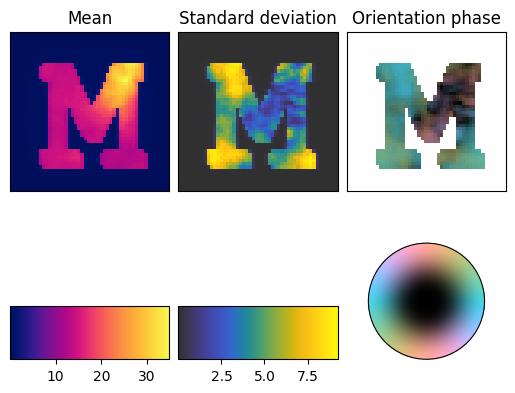

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
#The input files:
!wget -O saxstt_dataset_M.h5 https://zenodo.org/records/7326784/files/saxstt_dataset_M.h5
data_container = DataContainer('saxstt_dataset_M.h5')

#We can now take a quick look at the container object to see that the parameters make sense.
display(data_container)

#check out projections:
p = ProjectionViewer(data_container, orientation_symmetry='transversal')



Field,Size,Data
"Maximum ""ell""",1,6
"""ell"" indices",28,[0 2 ... 6 6]
"""emm"" indices",28,[ 0 -2 ... 5 6]
Coefficient projection matrix,"(1, 1, 28)",[[[ 1. 0. ... -0. 2.42]]]
Hash,16,af1e65


Field,Size,Data
is_dirty,1,False
hash,17,abf2e6


Field,Size,Data
BasisSet,1,SphericalHarmonics
Projector,13,SAXSProjector
Is dirty,1,False
probed_coordinates,"(417, 8, 3, 3)",0x5c17 (hash)
Hash,17,4c5d9a


Field,Size,Data
ResidualCalculator,1,GradientResidualCalculator
use_weights,1,False
preconditioner_hash,1,None
residual_norm_multiplier,1,1
Function of residual r,1,$L(r) = r^2$
Use preconditioner mask,1,True
Hash,18,1c376e


Field,Size,Data
Function of coefficients,1,$R(\vec{x}) = \lambda \frac{\Vert \nabla^2 \vec{x} \Vert^2}{2}$
Hash,18,1df556


...

  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/mumott/optimization/optimizers/lbfgs.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(fun=loss_function_wrapper, callback=progress_callback,


 10%|█         | 1/10 [03:52<34:52, 232.50s/it]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


100%|██████████| 10/10 [11:45<00:00, 70.52s/it]


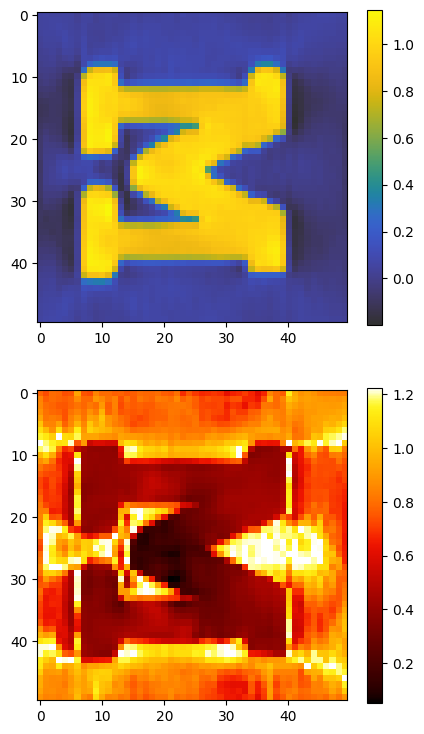

In [4]:
#We now need to choose a basis set
#SphericalHarmonics
basis_set = SphericalHarmonics(ell_max=6)
display(basis_set)
#SAXSProjector
projector = SAXSProjector(data_container.geometry)
display(projector)
#GradientResidualCalculator
residual_calculator = GradientResidualCalculator(
                                data_container=data_container,
                                basis_set=basis_set,
                                projector=projector)
display(residual_calculator)
#LossFunction
loss_function = SquaredLoss(residual_calculator)
display(loss_function)
#Laplacian
regularizer = Laplacian()
loss_function.add_regularizer(name='laplacian',
                              regularizer=regularizer,
                              regularization_weight=1e-1)
display(regularizer)
#Optimizer
optimizer = LBFGS(loss_function, maxiter=10)
display(optimizer)

results = optimizer.optimize()

#Visualizing the output
output = basis_set.get_output(residual_calculator.coefficients)
orientation = output.eigenvector_3
scale = output.mean_intensity
color = output.fractional_anisotropy

import colorcet
from matplotlib import colormaps as cm

orientation.shape
f, ax = plt.subplots(2, figsize=(5, 9))
image_0 = ax[0].imshow(scale[:, 25, :], cmap='cet_gouldian')
plt.colorbar(image_0, ax=ax[0])
image_1 = ax[1].imshow(color[:, 25, :], cmap='cet_fire')
plt.colorbar(image_1, ax=ax[1])
display(image_0)
display(image_1)



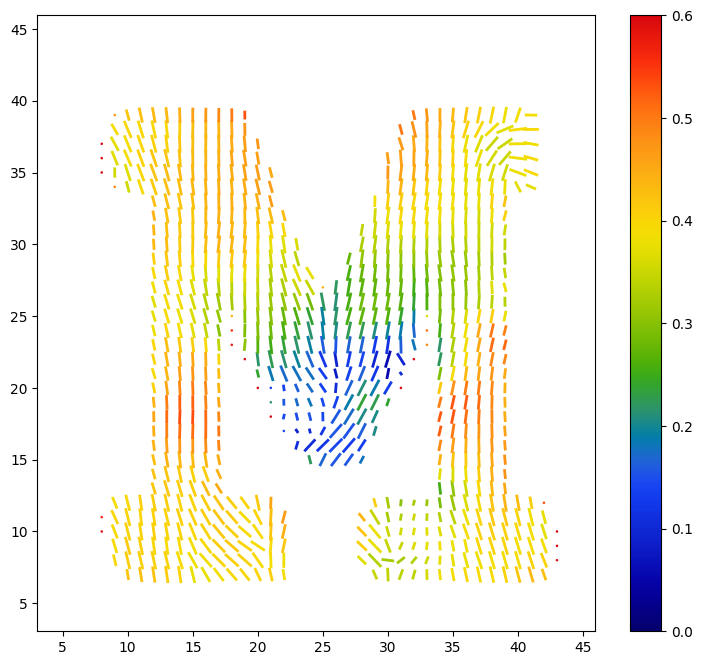

In [5]:
scale_cutoff = (0.3, 1.0)
color_cutoff = (0.0, 0.6)
test_scale = scale[5:45, 25, 5:45].clip(0, scale_cutoff[1])
test_scale[test_scale < scale_cutoff[0]] = np.nan
test_scale -= scale_cutoff[0]
test_scale /= (scale_cutoff[1] - scale_cutoff[0])
test_color = color[5:45, 25, 5:45].clip(*color_cutoff)
f, ax = plt.subplots(1, figsize=(9, 8))
x, y = np.meshgrid(np.arange(5, 45),
                   np.arange(5, 45),
                   indexing='ij')
test_orientation_x = orientation[5:45, 25, 5:45, 0] * test_scale
test_orientation_y = orientation[5:45, 25, 5:45, 2] * test_scale * np.sign(test_orientation_x)
test_orientation_x = abs(test_orientation_x)
q = ax.quiver(x, y, test_orientation_x, test_orientation_y,
              test_color, pivot='mid', angles='xy',
              headwidth=1, headlength=0, scale=30, width=0.005,
              cmap='cet_rainbow4', clim=color_cutoff)
plt.colorbar(q, ax=ax)
display(q)